In [58]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import time

In [59]:
portfolio_returns = pd.read_csv('../data/new.csv')
portfolio_returns

,DATE,quantile_4
0,2021-07,-0.045886
1,2021-08,0.007475
2,2021-09,0.095874
3,2021-10,-0.038462
4,2021-11,-0.056317
5,2021-12,0.001185
6,2022-01,-0.035614
7,2022-02,0.066788
8,2022-03,0.027534
9,2022-04,-0.000011


TypeError: MonthLocator.__init__() got an unexpected keyword argument 'bymonthlist'. Did you mean 'bymonthday'?

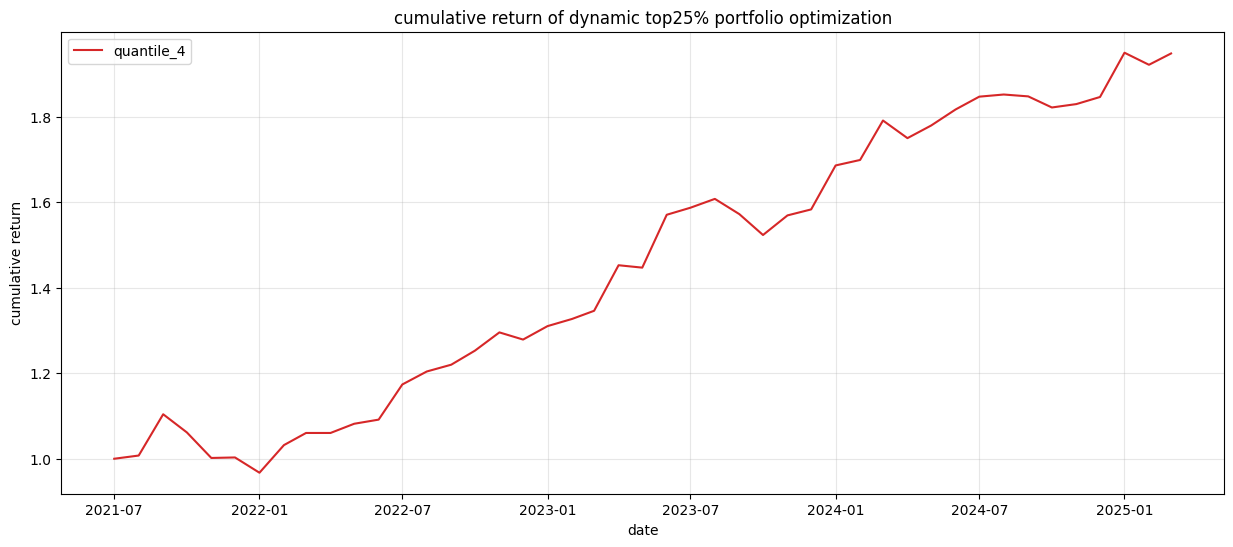

In [60]:
def plot_portfolio_returns(portfolio_returns):
    plt.figure(figsize=(15, 6))
    
    for col in portfolio_returns.columns:
        if col == 'DATE':  # DATEカラムはスキップ
            continue
            
        # 累計リターンを計算
        cumulative_returns = (1 + portfolio_returns[col]).cumprod()
        
        # 2021年7月を基点(1)になるように調整
        base_date = '2021-07'
        portfolio_returns_temp = portfolio_returns.copy()
        portfolio_returns_temp['DATE_str'] = portfolio_returns_temp['DATE'].dt.strftime('%Y-%m')
        
        if base_date in portfolio_returns_temp['DATE_str'].tolist():
            base_idx = portfolio_returns_temp[portfolio_returns_temp['DATE_str'] == base_date].index[0]
            base_value = cumulative_returns.loc[base_idx]
            cumulative_returns = cumulative_returns / base_value
        else:
            # 2021年7月がない場合は最初の値で正規化
            cumulative_returns = cumulative_returns / cumulative_returns.iloc[0]

        plt.plot(portfolio_returns['DATE'], 
                cumulative_returns, 
                label=col,
                color='#d62728',  # 赤色
                linewidth=1.5)

    plt.title('cumulative return of dynamic top25% portfolio optimization')
    plt.xlabel('date')
    plt.ylabel('cumulative return')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # x軸を7月起点で6ヶ月間隔に設定（7月、1月、7月、1月...）
    from matplotlib.dates import DateFormatter, MonthLocator
    import matplotlib.dates as mdates
    ax = plt.gca()
    
    # 7月起点で6ヶ月間隔の目盛りを設定
    # bymonthlist=[1, 7]で1月と7月に目盛りを設定
    ax.xaxis.set_major_locator(MonthLocator(bymonthlist=[1, 7]))
    ax.xaxis.set_major_formatter(DateFormatter('%Y-%m'))
    
    # y軸の範囲を画像に合わせて調整
    plt.ylim(0.85, 1.55)
    
    # tick_paramsを使って回転を設定
    ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()


# set date index
portfolio_returns['DATE'] = pd.to_datetime(portfolio_returns['DATE'])

# visualize growth rate
plot_portfolio_returns(portfolio_returns)